### 玻璃订单ERP系统对于烨辉油砂仓库的库存供需预测设计

由系统导出数据至data目录，包括订单发货记录、库存入库、出库记录及产品级别信息。

**核心指标**：
- 库存周转率 = 销售成本 ÷ 平均库存（衡量库存周转效率）
- 库存 $I_t = I_{t-1} + \text{入库}_t - \text{出库}_t$

**数据加载与预览**

使用 `pandas`、`numpy`、`plotly`、`matplotlib`、`statsmodels` 等库，读取 `data/聚合数据.csv`，并预览前几行以确认数据结构。

In [19]:
import pandas as pd
import numpy as np
import plotly.express as px
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

data = pd.read_csv("data/聚合数据.csv")
print("数据预览：")
print(data.head())

数据预览：
   Unnamed: 0        Date  Product_ID  Demand  Inventory
0           0  2025-10-31      101316       0          0
1           1  2025-10-31      101318       0          0
2           2  2025-10-31      101324       0          0
3           3  2025-10-31      101352       0          0
4           4  2025-10-31      101353       0          0


**数据清洗**

使用 `pandas` 的 `drop` 方法，删除多余的 `Unnamed: 0` 索引列，便于后续分析。

In [20]:
data.drop('Unnamed: 0', axis=1, inplace=True)

**需求量可视化**

使用 `plotly.express` 的 `px.line` 绘制折线图，展示需求量随时间的变化趋势，用于观察需求波动特征。

**当日需求量**：$D_t$ = 当日应发货出库量（对应 `Demand` 列）

In [21]:
fig_demand = px.line(data, x='Date',
                     y='Demand',
                     title='需求随时间变化',
                     labels={'Date': '日期', 'Demand': '需求量'})
fig_demand.show()

**库存量可视化**

使用 `plotly.express` 绘制折线图，展示库存量随时间的变化，用于观察库存走势及是否存在缺货风险。

**库存动态**：$I_t = I_{t-1} + \text{入库}_t - \text{出库}_t$，其中 $I_t$ 为第 $t$ 日末库存。

In [22]:
fig_inventory = px.line(data, x='Date',
                        y='Inventory',
                        title='库存随时间变化',
                        labels={'Date': '日期', 'Inventory': '库存量'})
fig_inventory.show()

**ACF/PACF 分析**：使用 **statsmodels** 的 `plot_acf`、`plot_pacf` 绘制自相关与偏自相关图，用于分析差分后时间序列的结构，辅助确定 ARIMA 的 p、q 阶数。

**自相关（ACF）**：$\rho_k = \frac{\text{Cov}(y_t, y_{t-k})}{\text{Var}(y_t)}$，衡量 $y_t$ 与 $y_{t-k}$ 的线性相关程度。

**偏自相关（PACF）**：$\phi_{kk}$ 为去除中间滞后影响后，$y_t$ 与 $y_{t-k}$ 的相关系数。

小样本差分序列观测数: 4
大样本差分序列观测数: 49


C:\Users\topfun\AppData\Local\Temp\ipykernel_27940\874881266.py:48: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\topfun\AppData\Local\Temp\ipykernel_27940\874881266.py:48: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\topfun\AppData\Local\Temp\ipykernel_27940\874881266.py:48: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\topfun\AppData\Local\Temp\ipykernel_27940\874881266.py:48: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\topfun\AppData\Local\Temp\ipykernel_27940\874881266.py:48: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\topfun\AppData\Local\Temp\ipykernel_27940\874881266.py:48: UserWarning: Glyph 24207 (\

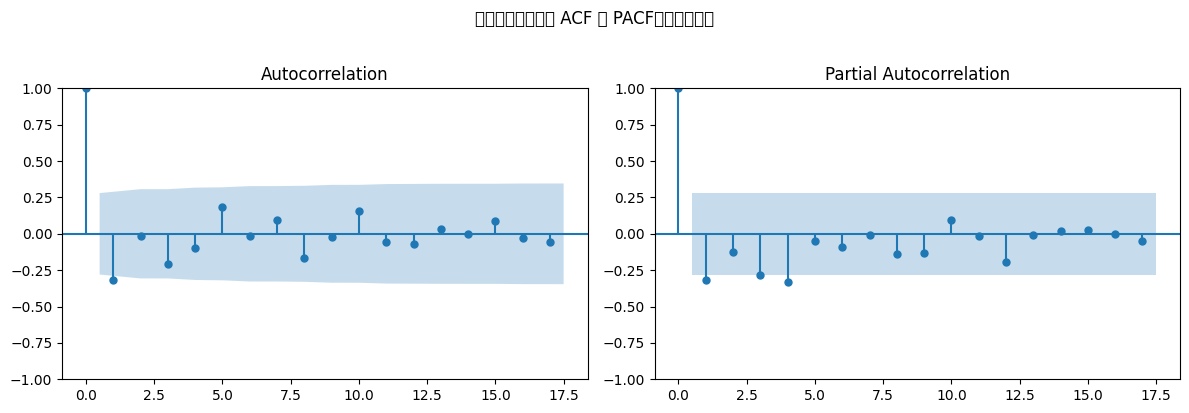

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import numpy as np

# 原代码（日期格式已修正）
# 假设 data 已加载，包含 Date 和 Demand 列
# 创建极小样本 DataFrame 用于复现问题：
# 仅 5 个数据点
data_small = pd.DataFrame({
    'Date': ['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04', '2023-01-05'],
    'Demand': [10, 12, 15, 13, 16]
})

data_small['Date'] = pd.to_datetime(data_small['Date'], format='%Y-%m-%d')
time_series_small = data_small.set_index('Date')['Demand']

differenced_series_small = time_series_small.diff().dropna()
print(f"小样本差分序列观测数: {len(differenced_series_small)}")
# data_small: len(differenced_series_small) 为 4
# 4 // 2 - 1 = 1，默认 nlags 计算会超过 1，导致报错

# 解决方案：使用更多数据
# 创建较大样本（如 50 个数据点）
dates = pd.date_range(start='2023-01-01', periods=50, freq='D')
demand = np.random.randint(50, 100, size=50) + np.arange(50) * 0.5 # Adding a trend for illustration
data_larger = pd.DataFrame({
    'Date': dates,
    'Demand': demand
})

data_larger['Date'] = pd.to_datetime(data_larger['Date'], format='%Y-%m-%d')
time_series_larger = data_larger.set_index('Date')['Demand']

differenced_series_larger = time_series_larger.diff().dropna()
print(f"大样本差分序列观测数: {len(differenced_series_larger)}")
# data_larger: len(differenced_series_larger) 为 49，默认 nlags 足够

# 绘制差分后序列的 ACF 和 PACF 图
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(differenced_series_larger, ax=axes[0])
plot_pacf(differenced_series_larger, ax=axes[1])
plt.suptitle('差分后时间序列的 ACF 与 PACF（数据充足）', y=1.02)
plt.tight_layout()
plt.show()

**ARIMA 预测**：使用 **statsmodels** 的 `SARIMAX` 搭建非季节性 ARIMA(1,1,1) 模型，用于训练并预测未来若干天的需求量，为库存参数计算提供输入。

**ARIMA(p,d,q) 模型**（$y_t' = \nabla^d y_t$ 为 d 阶差分后序列）：

$$y_t' = c + \phi_1 y_{t-1}' + \cdots + \phi_p y_{t-p}' + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \cdots + \theta_q \varepsilon_{t-q}$$

其中 $\varepsilon_t$ 为白噪声。ARIMA(1,1,1) 即 p=1, d=1, q=1。

2023-03-02    70
2023-03-03    72
2023-03-04    72
2023-03-05    73
2023-03-06    73
2023-03-07    73
2023-03-08    73
2023-03-09    73
2023-03-10    73
2023-03-11    73
Freq: D, Name: predicted_mean, dtype: int64


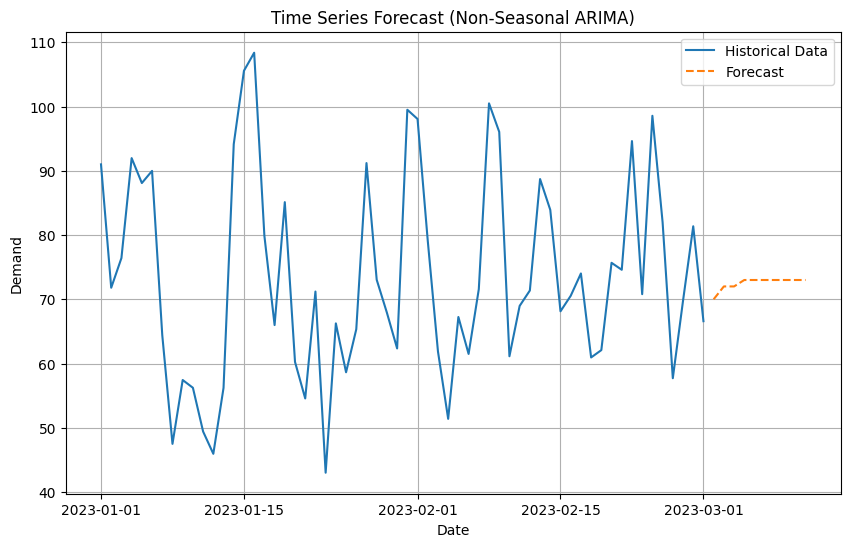

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 假设 time_series 已创建，表示 2 个月数据
# 演示用：创建跨度 2 个月的时间序列
dates = pd.date_range(start='2023-01-01', periods=60, freq='D') # 60 天，约 2 个月
demand = np.random.randint(50, 100, size=60) + np.sin(np.arange(60) * 0.5) * 10
time_series = pd.Series(demand, index=dates, name='Demand')

# 1. 移除 seasonal_order 季节项
order = (1, 1, 1) # 非季节性 ARIMA (p, d, q)
# 等价于 seasonal_order=(0, 0, 0, 0)
# model = SARIMAX(time_series, order=order, seasonal_order=(0, 0, 0, 0))  # 或直接省略 seasonal_order

model = SARIMAX(time_series, order=order) # This is equivalent to seasonal_order=(0,0,0,0)
model_fit = model.fit(disp=False)

future_steps = 10
predictions = model_fit.predict(len(time_series), len(time_series) + future_steps - 1)
predictions = predictions.astype(int)
print(predictions)

# 可选：绘图展示
plt.figure(figsize=(10, 6))
plt.plot(time_series.index, time_series, label='历史数据')
forecast_index = pd.date_range(start=time_series.index[-1], periods=future_steps + 1, freq='D')[1:]
plt.plot(forecast_index, predictions, label='预测值', linestyle='--')
plt.title('时间序列预测（非季节性 ARIMA）')
plt.xlabel('日期')
plt.ylabel('需求量')
plt.legend()
plt.grid(True)
plt.show()

**库存参数计算**：基于预测需求，使用 **numpy** 和报童公式，计算最优订货量、再订货点、安全库存及总成本（持有成本 + 缺货成本），用于指导补货决策。

**计算公式**（$\bar{D}$ 为预测日均需求，$L$ 为提前期，$z_\alpha$ 为服务水平 $\alpha$ 对应分位数）：

- **再订货点**：$R = \bar{D} \cdot L + z_\alpha$
- **安全库存**：$SS = R - \bar{D} \cdot L = z_\alpha$
- **最优订货量**：$Q^* = \lceil \bar{D} + z_\alpha \rceil$
- **总成本**：$TC = h \cdot (I + \frac{Q}{2}) + k \cdot \max(0, \bar{D} \cdot L - I)$  

其中 $h$ 为持有成本率，$k$ 为缺货成本，$I$ 为初始库存。

In [26]:
# 创建未来预测的日期索引
future_dates = pd.date_range(start=time_series.index[-1] + pd.DateOffset(days=1), periods=future_steps, freq='D')

# 创建带日期索引的预测序列
forecasted_demand = pd.Series(predictions, index=future_dates)

# 初始库存水平
initial_inventory = 5500

# 提前期（补货所需天数）
lead_time = 1  # 示例值，按实际业务调整

# 服务水平（不缺货概率）
service_level = 0.95  # 示例值，按实际业务调整

# 使用报童公式计算最优订货量
z = np.abs(np.percentile(forecasted_demand, 100 * (1 - service_level)))
order_quantity = np.ceil(forecasted_demand.mean() + z).astype(int)

# 计算再订货点
reorder_point = forecasted_demand.mean() * lead_time + z

# 计算安全库存
safety_stock = reorder_point - forecasted_demand.mean() * lead_time

# 计算总成本（持有成本 + 缺货成本）
holding_cost = 0.1   # 示例值
stockout_cost = 10  # 示例值
total_holding_cost = holding_cost * (initial_inventory + 0.5 * order_quantity)
total_stockout_cost = stockout_cost * np.maximum(0, forecasted_demand.mean() * lead_time - initial_inventory)

# 汇总总成本
total_cost = total_holding_cost + total_stockout_cost

print("最优订货量:", order_quantity)
print("再订货点:", reorder_point)
print("安全库存:", safety_stock)
print("总成本:", total_cost)

最优订货量: 144
再订货点: 143.4
安全库存: 70.9
总成本: 557.2
